In [120]:
import pandas as pd
df = pd.read_csv("../data/raw/synthetic_mmm_weekly_india_SAT.csv",
               parse_dates=["Week"])
df.info()
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11232 entries, 0 to 11231
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week                     11232 non-null  datetime64[ns]
 1   Geo                      11232 non-null  object        
 2   Brand                    11232 non-null  object        
 3   SKU                      11232 non-null  object        
 4   Sales_Units              11232 non-null  float64       
 5   Sales_Value              11232 non-null  float64       
 6   MRP                      11232 non-null  float64       
 7   Net_Price                11232 non-null  float64       
 8   Feature_Flag             11232 non-null  int64         
 9   Display_Flag             11232 non-null  int64         
 10  TPR_Flag                 11232 non-null  int64         
 11  Trade_Spend              11232 non-null  float64       
 12  TV_Impressions           11232 n

,Week,Geo,Brand,SKU,Sales_Units,Sales_Value,MRP,Net_Price,Feature_Flag,Display_Flag,...,FB_Banner_Content_Score,IG_Banner_Content_Score,Weighted_Distribution,Numeric_Distribution,TDP,NOS,CPI,GDP_Growth,Festival_Index,Rainfall_Index
0,2022-07-02,CENTRAL,BrandA,BrandA_SKU1,166.737425,15058.472804,90.312495,90.312495,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
1,2022-07-02,CENTRAL,BrandA,BrandA_SKU2,123.326990,11166.439172,90.543353,90.543353,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
2,2022-07-02,CENTRAL,BrandA,BrandA_SKU3,74.232953,7829.352426,105.470039,105.470039,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
3,2022-07-02,CENTRAL,BrandB,BrandB_SKU1,216.583770,15986.585046,73.812479,73.812479,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544
4,2022-07-02,CENTRAL,BrandB,BrandB_SKU2,272.920195,22565.283219,82.680885,82.680885,0,0,...,75.63537,86.52171,0.456192,0.360998,33.70972,2.986547,118.843878,5.464558,0.934774,4.587544


In [121]:
aggregation_rules = {
    'Sales_Value': 'sum',
    'TV_Impressions': 'max', # Takes the brand-level total once
    'YouTube_Impressions': 'max',
    'Facebook_Impressions': 'max',
    'Instagram_Impressions': 'max',
    'Trade_Spend': 'max',
    'Net_Price': 'mean'
}

geo_brand = df.groupby(["Week", "Geo", "Brand"], as_index=False).agg(aggregation_rules)

In [122]:
import numpy as np
m = geo_brand.copy()
m["log_sales_val"] = np.log1p(m["Sales_Value"])
m["price_index"] = m["Net_Price"] / m.groupby(["Geo","Brand"])["Net_Price"].transform("mean")


In [123]:
df["Week_Start"] = df["Week"] - pd.Timedelta(days=6)

In [124]:
# Market-calibrated CPMs for India (2024-2025 benchmarks)
RESEARCHED_CPMS = {
    'TV': 60,           
    'YouTube': 250,      
    'Facebook': 110,     
    'Instagram': 180    
}


# Calculate Spend using researched CPM benchmarks
# We divide by 1000 to turn Impressions into "Units of 1000"
m['TV_Spend'] = (m['TV_Impressions'] / 1000) * RESEARCHED_CPMS['TV']
m['YouTube_Spend'] = (m['YouTube_Impressions'] / 1000) * RESEARCHED_CPMS['YouTube']
m['Facebook_Spend'] = (m['Facebook_Impressions'] / 1000) * RESEARCHED_CPMS['Facebook']
m['Instagram_Spend'] = (m['Instagram_Impressions'] / 1000) * RESEARCHED_CPMS['Instagram']

# Final Marketing Spend Calculation
marketing_channels = ['TV_Spend', 'YouTube_Spend', 'Facebook_Spend', 'Instagram_Spend', 'Trade_Spend']
m['Total_Spend'] = m[marketing_channels].sum(axis=1)

#ROI calculation
m['naive_roi'] = m['Sales_Value'] / (m['Total_Spend'] + 1e-6)

#creating lagged features
m['TV_Spend_Lag1'] = m.groupby(['Geo', 'Brand'])['TV_Spend'].shift(1)
m['YouTube_Spend_Lag1'] = m.groupby(['Geo', 'Brand'])['YouTube_Spend'].shift(1)
m['Facebook_Spend_Lag1'] = m.groupby(['Geo', 'Brand'])['Facebook_Spend'].shift(1)
m['Instagram_Spend_Lag1'] = m.groupby(['Geo', 'Brand'])['Instagram_Spend'].shift(1)

# Essential: Handle the NaNs created by shifting
m.fillna(0, inplace=True)


print(m[['Brand', 'Sales_Value', 'Total_Spend', 'naive_roi']].head())

    Brand   Sales_Value    Total_Spend  naive_roi
0  BrandA  34054.264402  223252.552826   0.152537
1  BrandB  43537.095662  168232.630650   0.258791
2  BrandC  15606.889435  108981.951410   0.143206
3  BrandA  53794.394906  225608.699933   0.238441
4  BrandB  39371.341028  213351.509880   0.184537


In [125]:
# 1. Overall Business KPIs
total_revenue = m['Sales_Value'].sum()
total_spend = m[marketing_channels].sum().sum()
overall_roi = total_revenue / total_spend

# 2. Channel-Specific Breakdown
# We'll create a summary table for Spend
spend_summary = m[marketing_channels].agg(['sum', 'mean', 'median']).T
spend_summary.columns = ['Total Spend', 'Mean Spend', 'Median Spend']

# 3. Display the results formatted for clarity
print("--- OVERALL BUSINESS PERFORMANCE ---")
print(f"Total Revenue:   ₹{total_revenue:,.2f}")
print(f"Total Spend:     ₹{total_spend:,.2f}")
print(f"Overall ROI:     {overall_roi:.2f}x")
print("\n--- CHANNEL SPENDING BEHAVIOR ---")
print(spend_summary.round(2))

--- OVERALL BUSINESS PERFORMANCE ---
Total Revenue:   ₹364,516,965.53
Total Spend:     ₹1,342,762,824.57
Overall ROI:     0.27x

--- CHANNEL SPENDING BEHAVIOR ---
                  Total Spend  Mean Spend  Median Spend
TV_Spend         2.752647e+08    73521.54      55495.14
YouTube_Spend    5.509395e+08   147152.63     106973.01
Facebook_Spend   1.933971e+08    51655.21      36692.57
Instagram_Spend  1.105621e+08    29530.46      24894.11
Trade_Spend      2.125995e+08    56784.06      21045.40


In [126]:
#create priors for business knowledge
total_spend_per_channel = m[['TV_Spend', 'YouTube_Spend', 'Facebook_Spend','Instagram_Spend','Trade_Spend']].sum(axis=0)
spend_proportion = total_spend_per_channel/ total_spend_per_channel.sum()
print(spend_proportion)

TV_Spend           0.204999
YouTube_Spend      0.410303
Facebook_Spend     0.144029
Instagram_Spend    0.082339
Trade_Spend        0.158330
dtype: float64


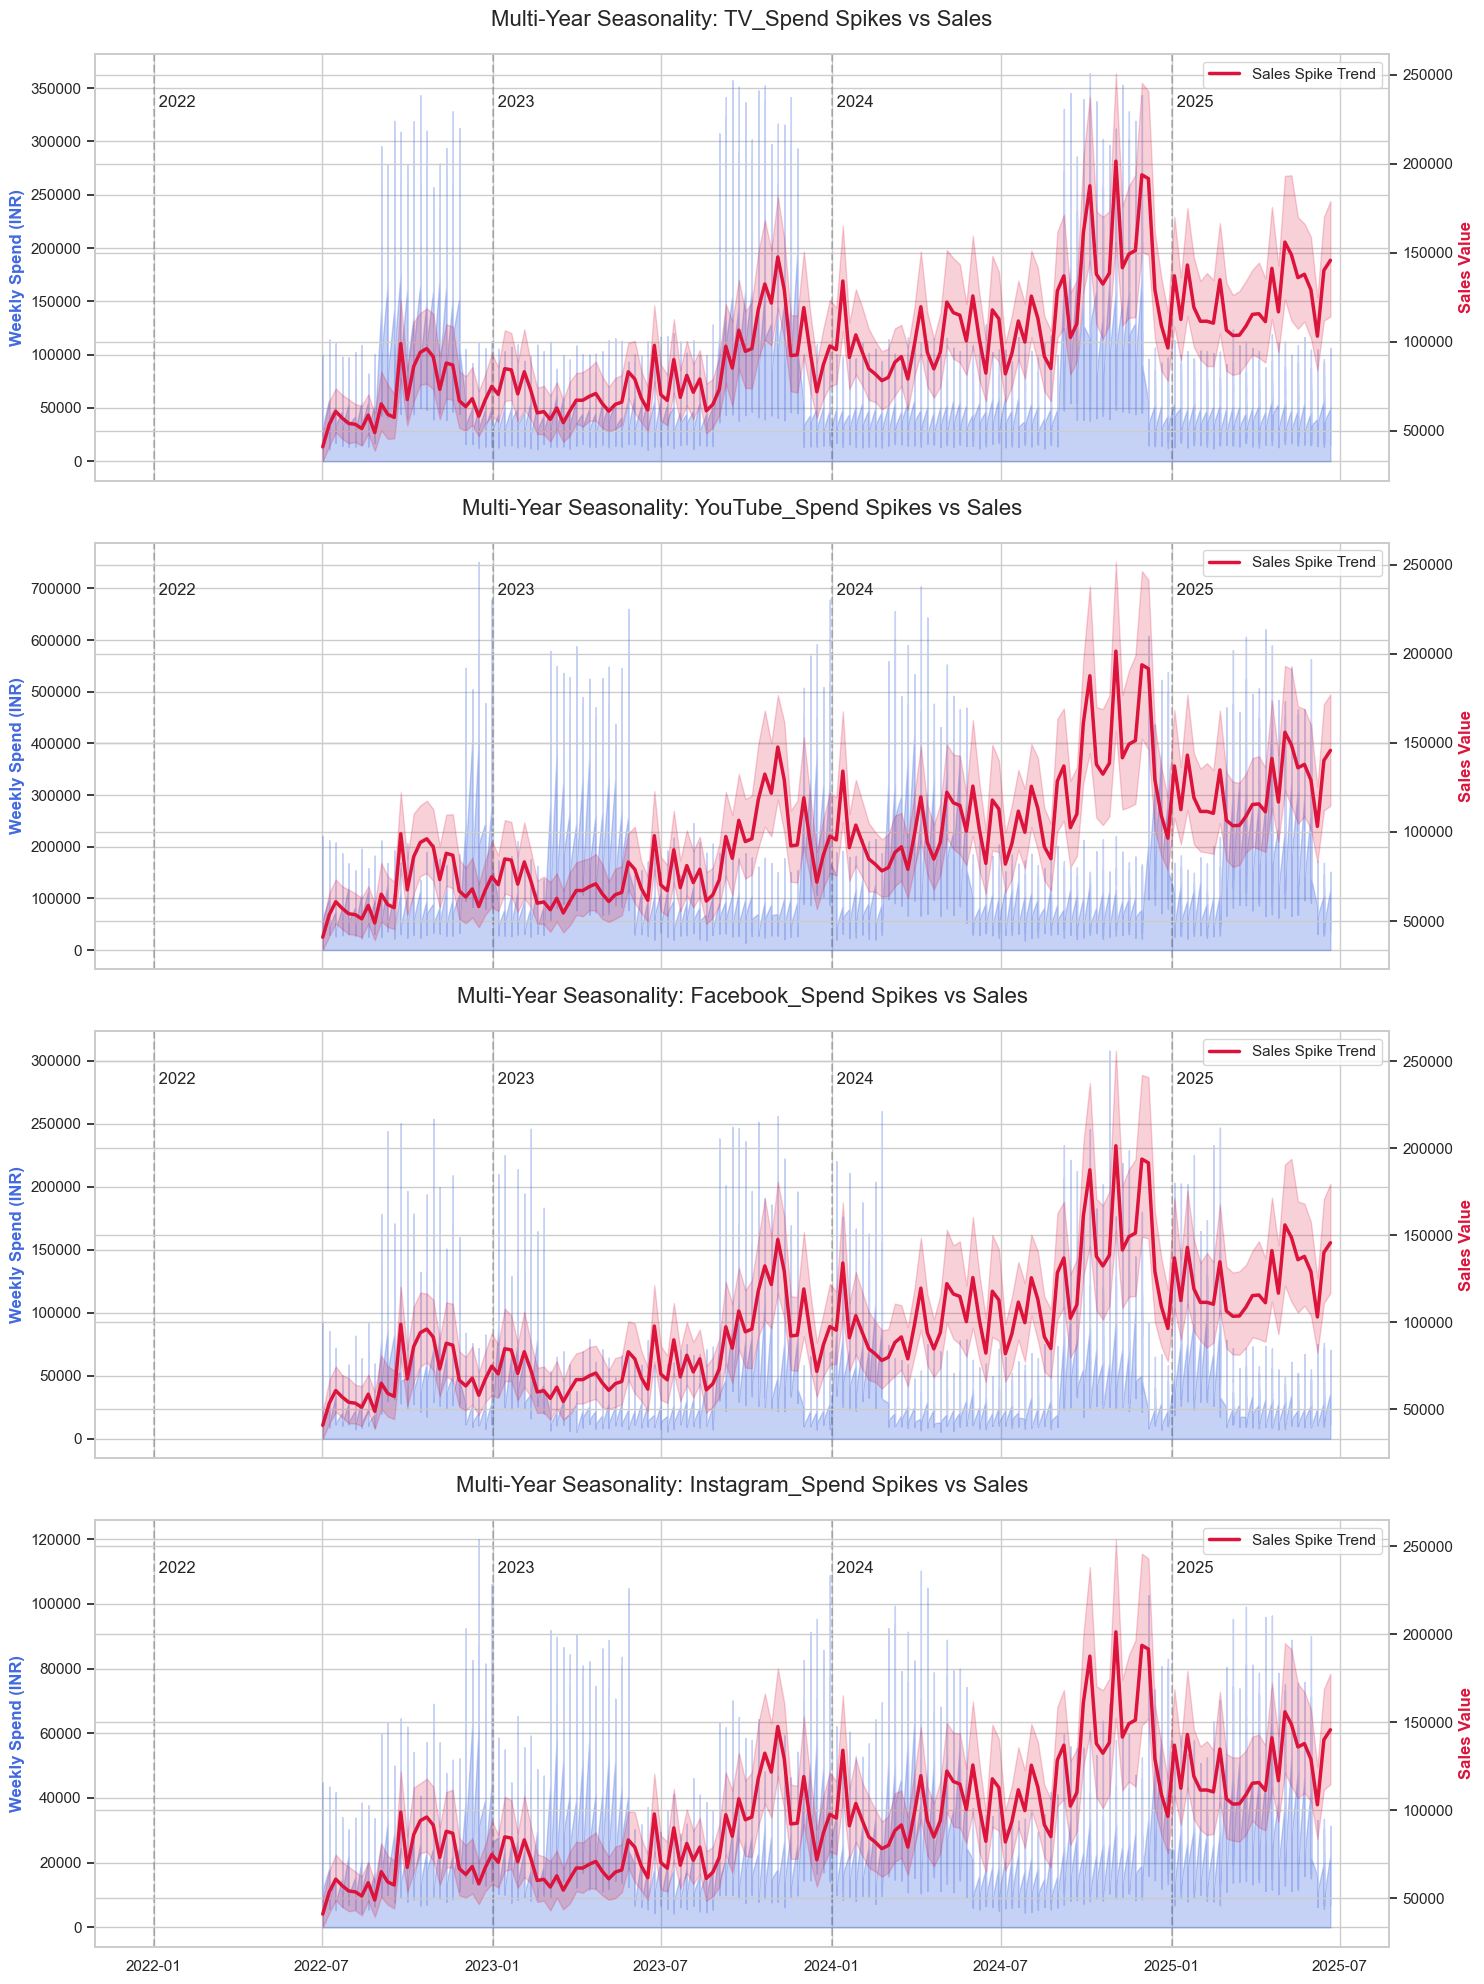

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Week' is a datetime object so we can extract the year
m['Week'] = pd.to_datetime(m['Week'])

sns.set_theme(style="whitegrid")
channels = ['TV_Spend', 'YouTube_Spend', 'Facebook_Spend', 'Instagram_Spend']

# Create the figure
fig, axes = plt.subplots(len(channels), 1, figsize=(15, 20), sharex=True)

for i, channel in enumerate(channels):
    ax_spend = axes[i]
    ax_sales = ax_spend.twinx()
    
    # Plotting Spend as an area to show the "volume" of investment over the years
    ax_spend.fill_between(m['Week'], m[channel], color='royalblue', alpha=0.3, label=f'Yearly {channel} Activity')
    ax_spend.set_ylabel('Weekly Spend (INR)', color='royalblue', fontweight='bold')
    
    # Plotting Sales as a high-contrast line to see the "Result"
    sns.lineplot(data=m, x='Week', y='Sales_Value', ax=ax_sales, color='crimson', linewidth=2.5, label='Sales Spike Trend')
    ax_sales.set_ylabel('Sales Value', color='crimson', fontweight='bold')
    
    # Add vertical lines for the start of each year to help identify "Yearly" cycles
    years = m['Week'].dt.year.unique()
    for year in years:
        year_start = pd.Timestamp(year=year, month=1, day=1)
        ax_spend.axvline(year_start, color='black', linestyle='--', alpha=0.2)
        ax_spend.text(year_start, ax_spend.get_ylim()[1]*0.9, f' {year}', fontsize=12, verticalalignment='top')

    ax_spend.set_title(f'Multi-Year Seasonality: {channel} Spikes vs Sales', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

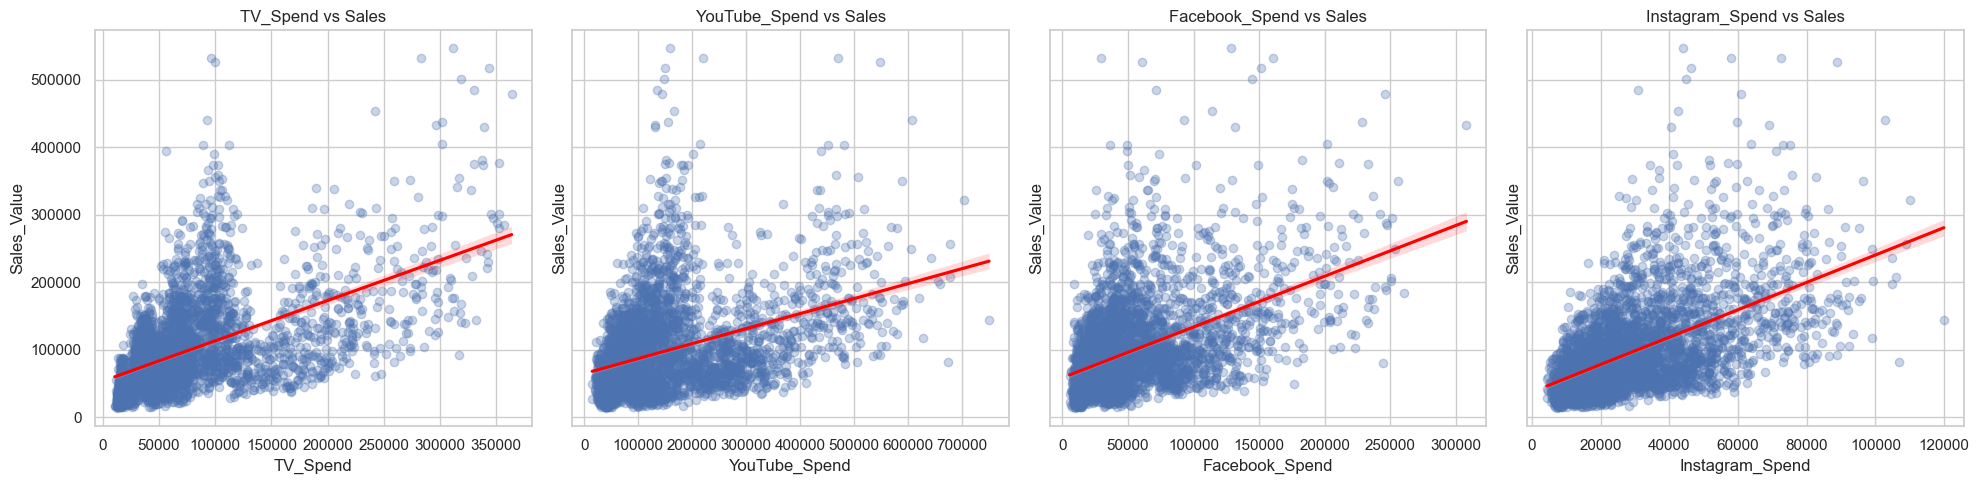

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice visual style
sns.set_theme(style="whitegrid")

# Create a figure with subplots for each channel
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

channels = ['TV_Spend', 'YouTube_Spend', 'Facebook_Spend', 'Instagram_Spend']

for i, col in enumerate(channels):
    sns.regplot(x=col, y='Sales_Value', data=m, ax=axes[i], 
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Sales')

plt.tight_layout()
plt.show()

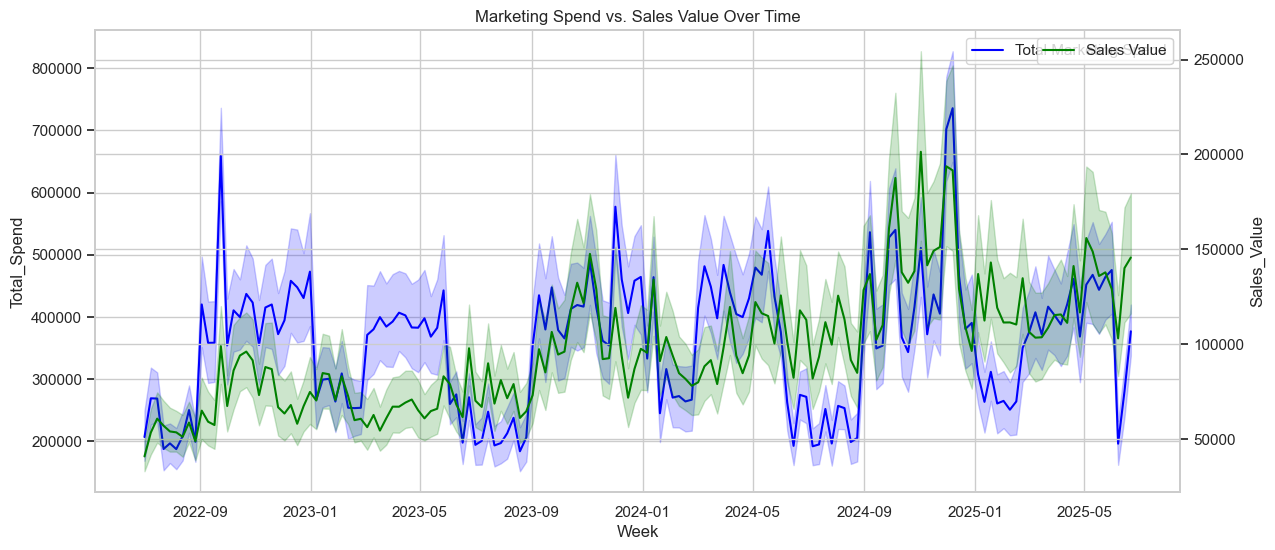

In [129]:
plt.figure(figsize=(14, 6))

# Plot Total Spend
sns.lineplot(data=m, x='Week', y='Total_Spend', label='Total Marketing Spend', color='blue')

# Create a second y-axis for Sales
ax2 = plt.twinx()
sns.lineplot(data=m, x='Week', y='Sales_Value', label='Sales Value', color='green', ax=ax2)

plt.title('Marketing Spend vs. Sales Value Over Time')
plt.show()

In [130]:
#export processed data

m.to_csv("../data/processed/cleaned_marketing_data.csv", index=False)